In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("house_price_regression_dataset.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [8]:
df.isna()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False


In [9]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [10]:
df.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [23]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


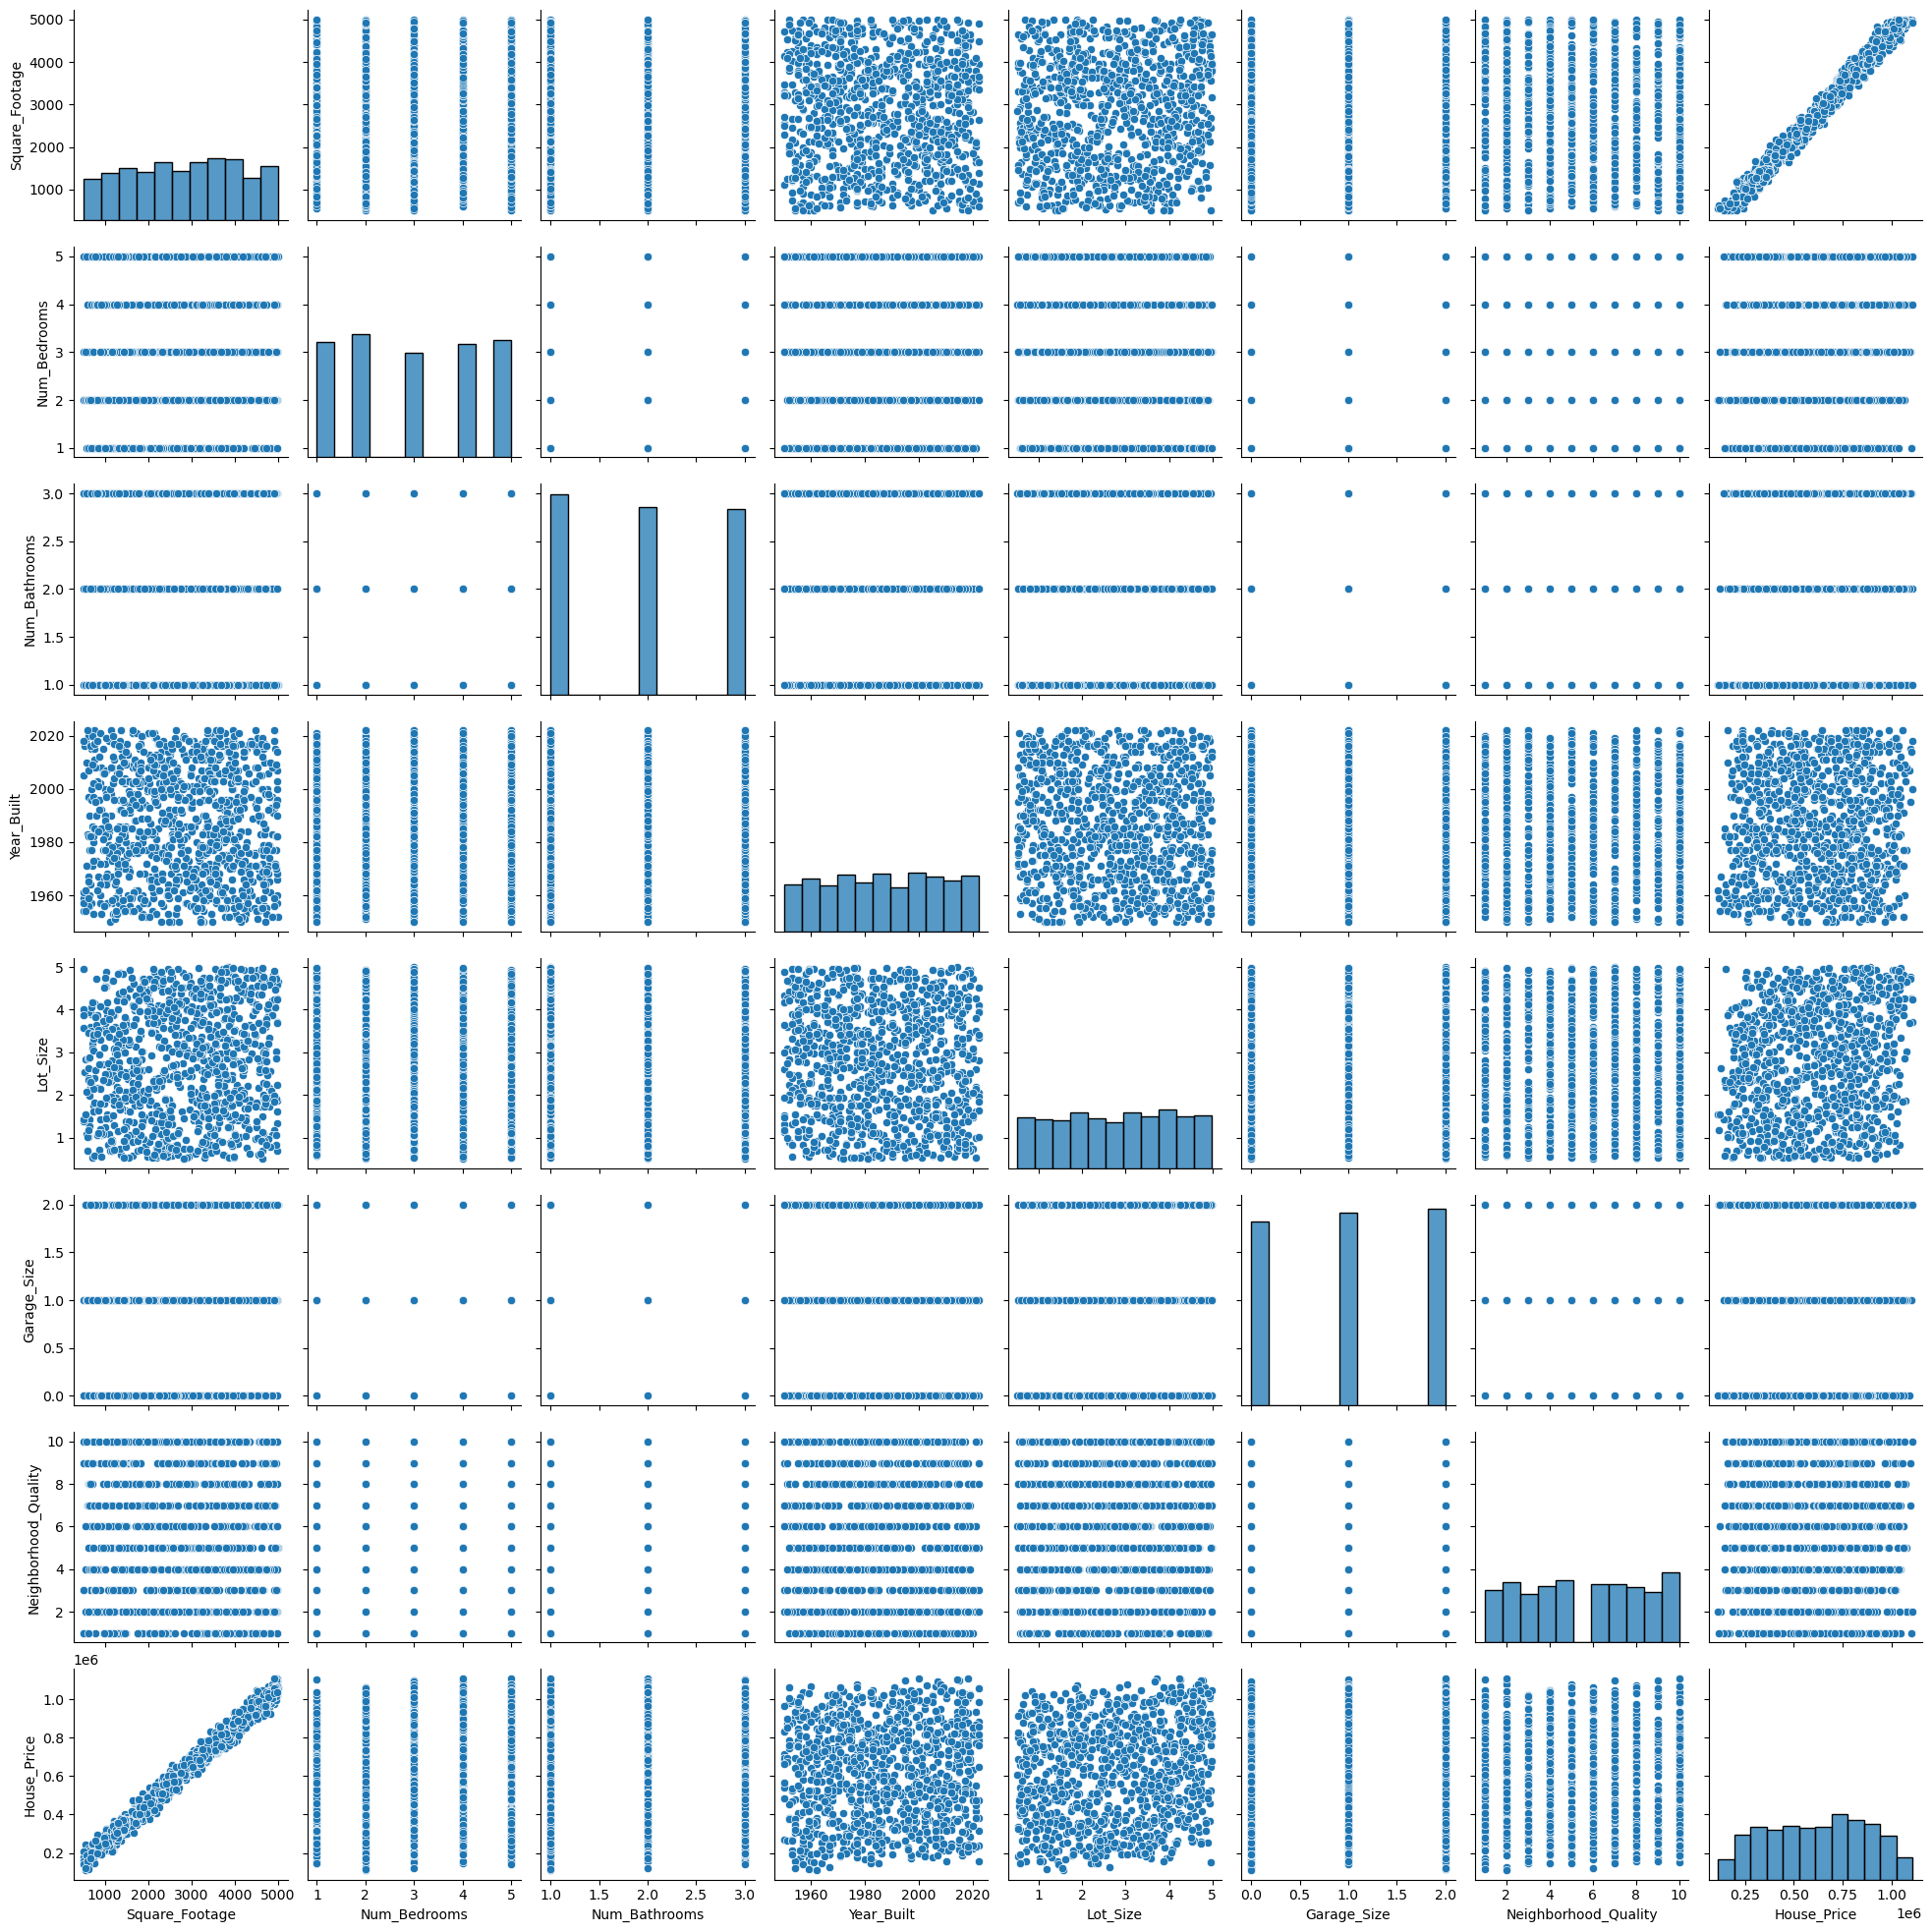

In [25]:
sns.pairplot(df)
plt.show()

In [32]:
# 1. Adım: Hedef değişkeni (y) ayırıyoruz
# Tahmin etmek istediğimiz şey evin fiyatı
y = df["House_Price"]

# 2. Adım: Bağımsız değişkenleri (X) ayırıyoruz
# 'House_Price' sütununu çıkarıp geri kalan her şeyi alıyoruz
X = df.drop("House_Price", axis=1)

# Kontrol etmek için:
print("X (Girdiler) Sütunları:", X.columns.tolist())
print("y (Hedef) Örneği:\n", y.head())

X (Girdiler) Sütunları: ['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built', 'Lot_Size', 'Garage_Size', 'Neighborhood_Quality']
y (Hedef) Örneği:
 0    2.623829e+05
1    9.852609e+05
2    7.779774e+05
3    2.296989e+05
4    1.041741e+06
Name: House_Price, dtype: float64


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Veriyi Eğitim ve Test setine bölme (%80 Eğitim, %20 Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN için X değerlerini ölçeklendirme (ÇOK ÖNEMLİ)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
from sklearn.tree import DecisionTreeRegressor

tree_model=DecisionTreeRegressor()
# Doğru olan: Eğitim soruları (X_train) ve Eğitim cevapları (y_train)
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [37]:
y_pred=tree_model.predict(X_test)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # MSE'nin karekökü
r2 = r2_score(y_test, y_pred)

# 3. Sonuçları Yazdıralım
print(f"MAE (Ortalama Mutlak Hata): {mae:.2f} TL")
print(f"RMSE (Kök Ortalama Kare Hata): {rmse:.2f} TL")
print(f"R² (Belirleyicilik Katsayısı): {r2:.4f}")

MAE (Ortalama Mutlak Hata): 25493.55 TL
RMSE (Kök Ortalama Kare Hata): 32761.17 TL
R² (Belirleyicilik Katsayısı): 0.9833


In [40]:
param={
   "criterion":["squared_error", "friedman_mse", "absolute_error", "poisson"],
    "splitter":["best", "random"],
    "max_depth":[1,2,3,4,5,None],
    "max_features":[1,2,3,"sqrt", "log2"]
    
}

In [42]:
from sklearn.model_selection import GridSearchCV

grid=GridSearchCV(estimator=DecisionTreeRegressor(),param_grid=param,cv=5,scoring="r2")

In [43]:
grid.fit(X_train, y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': [1, 2, ...], 'splitter': ['best', 'random']}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [44]:
print("En iyi parametreler:", grid.best_params_)
print("En iyi R² skoru:", grid.best_score_)

En iyi parametreler: {'criterion': 'squared_error', 'max_depth': 5, 'max_features': 3, 'splitter': 'best'}
En iyi R² skoru: 0.9159795627033638


In [45]:
# 1. En iyi parametrelerle eğitilmiş modeli kullanalım
best_tree_model = grid.best_estimator_

# 2. Tahminleri alalım
y_pred_final = best_tree_model.predict(X_test)

# 3. Metrikleri hesaplayalım
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_final = mean_absolute_error(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

# 4. Sonuçları yazdıralım
print(f"Yeni MAE: {mae_final:.2f} TL")
print(f"Yeni RMSE: {rmse_final:.2f} TL")
print(f"Yeni R²: {r2_final:.4f}")

Yeni MAE: 53201.95 TL
Yeni RMSE: 73515.11 TL
Yeni R²: 0.9162
